# install qiskit and numpy:

In [ ]:
%pip install qiskit # needed in colab

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.3/9.3 MB 67.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.2/2.2 MB 77.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 54.6/54.6 kB 3.5 MB/s eta 0:00:00


### if you use google colab, you'll need to import this for circuit drawing:

In [ ]:
%pip install pylatexenc

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 162.6/162.6 kB 3.6 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
  Created wheel for pylatexenc: filename=pylatexenc-2.10-py3-none-any.whl size=136817 sha256=395a657342029bd298ff8066ed2a112f8462e1dc33256fd07d2677f8dc6a4968
  Stored in directory: /root/.cache/pip/wheels/06/3e/78/fa1588c1ae991bbfd814af2bcac6cef7a178beee1939180d46
Successfully built pylatexenc


In [ ]:
import pylatexenc

## you can import qiskit as a whole via `import qiskit`, or just the parts you needs:

In [ ]:
from qiskit.circuit import QuantumCircuit, QuantumRegister, AncillaRegister
from qiskit.quantum_info import Operator, Statevector

import numpy as np

### PS: later we will use simulators, such as `qiskit_aer`, but for now we only use `Operator` and `Statevector` to analyse our circuits. in fact, I recommend simulating circuit only when they are necessary.

# Example circuit:

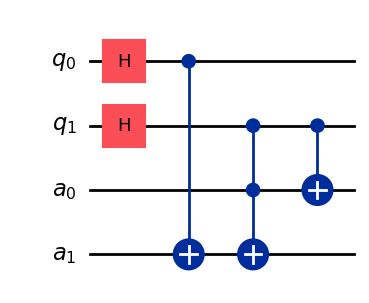

In [ ]:
quantum_register = QuantumRegister(size=2, name="q")
ancilla_register = AncillaRegister(size=2, name="a")

quantum_circuit = QuantumCircuit(quantum_register, ancilla_register, name="example circuit")

quantum_circuit.h(quantum_register)
quantum_circuit.cx(quantum_register[0], ancilla_register[1])
quantum_circuit.ccx(quantum_register[1], ancilla_register[0], ancilla_register[1])
quantum_circuit.cx(quantum_register[1], ancilla_register[0])

quantum_circuit.draw(output="mpl")

## the `Operator` outputs the unitary matrix corresponding to the quantum circuit:

In [ ]:
O = Operator(quantum_circuit)
O

Operator([[ 0.5+0.j,  0.5+0.j,  0.5+0.j,  0.5+0.j,  0. +0.j,  0. +0.j,
            0. +0.j,  0. +0.j,  0. +0.j,  0. +0.j,  0. +0.j,  0. +0.j,
            0. +0.j,  0. +0.j,  0. +0.j,  0. +0.j],
          [ 0. +0.j,  0. +0.j,  0. +0.j,  0. +0.j,  0. +0.j,  0. +0.j,
            0. +0.j,  0. +0.j,  0.5+0.j, -0.5+0.j,  0.5+0.j, -0.5+0.j,
            0. +0.j,  0. +0.j,  0. +0.j,  0. +0.j],
          [ 0. +0.j,  0. +0.j,  0. +0.j,  0. +0.j,  0. +0.j,  0. +0.j,
            0. +0.j,  0. +0.j,  0. +0.j,  0. +0.j,  0. +0.j,  0. +0.j,
            0.5+0.j,  0.5+0.j, -0.5+0.j, -0.5+0.j],
          [ 0. +0.j,  0. +0.j,  0. +0.j,  0. +0.j,  0.5+0.j, -0.5+0.j,
           -0.5+0.j,  0.5+0.j,  0. +0.j,  0. +0.j,  0. +0.j,  0. +0.j,
            0. +0.j,  0. +0.j,  0. +0.j,  0. +0.j],
          [ 0. +0.j,  0. +0.j,  0. +0.j,  0. +0.j,  0.5+0.j,  0.5+0.j,
            0.5+0.j,  0.5+0.j,  0. +0.j,  0. +0.j,  0. +0.j,  0. +0.j,
            0. +0.j,  0. +0.j,  0. +0.j,  0. +0.j],
          [ 0. +0.j,  0. +0.j,

## the `Statevector` outputs the statevector you get when applying the circuit to the initial all-zero state, $|000\rangle$:

In [ ]:
psi = Statevector(quantum_circuit)
psi

Statevector([0.5+0.j, 0. +0.j, 0. +0.j, 0. +0.j, 0. +0.j, 0. +0.j, 0.5+0.j,
             0. +0.j, 0. +0.j, 0.5+0.j, 0. +0.j, 0. +0.j, 0. +0.j, 0. +0.j,
             0. +0.j, 0.5+0.j],
            dims=(2, 2, 2, 2))


### check: psi is, in fact, the first column of O:

In [ ]:
np.array_equal(np.array(psi), np.array(O)[:, 0])

True

# Important elementary gates

## Pauli matricies

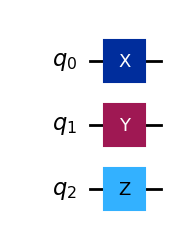

In [ ]:
quantum_register = QuantumRegister(size=3, name="q")

quantum_circuit = QuantumCircuit(quantum_register, name="example circuit")

# add Pauli X
quantum_circuit.x(quantum_register[0])

# add Pauli Y
quantum_circuit.y(quantum_register[1])

# add Pauli Z
quantum_circuit.z(quantum_register[2])

quantum_circuit.draw(output="mpl")

## rotations

https://quantum.cloud.ibm.com/docs/en/api/qiskit/qiskit.circuit.library.UCRXGate

https://quantum.cloud.ibm.com/docs/en/api/qiskit/qiskit.circuit.library.UCRYGate

https://quantum.cloud.ibm.com/docs/en/api/qiskit/qiskit.circuit.library.UCRZGate

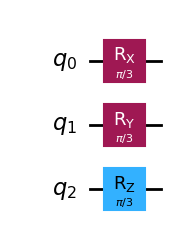

In [ ]:
quantum_register = QuantumRegister(size=3, name="q")

quantum_circuit = QuantumCircuit(quantum_register, name="example circuit")

# add rotation around X axis
quantum_circuit.rx(np.pi / 3, quantum_register[0], )

# add rotation around Y axis
quantum_circuit.ry(np.pi / 3, quantum_register[1])

# add rotation around Z axis
quantum_circuit.rz(np.pi / 3, quantum_register[2])

quantum_circuit.draw(output="mpl")

## phase gate

https://quantum.cloud.ibm.com/docs/en/api/qiskit/qiskit.circuit.library.PhaseGate

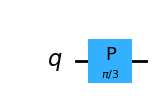

In [ ]:
quantum_register = QuantumRegister(size=1, name="q")

quantum_circuit = QuantumCircuit(quantum_register, name="example circuit")

# add a phase gate
quantum_circuit.p(np.pi / 3, quantum_register[0], )

quantum_circuit.draw(output="mpl")

### note: RZ and the phase gates are physically equivalent.

## general 1-qubit gate

https://quantum.cloud.ibm.com/docs/en/api/qiskit/qiskit.circuit.library.UGate

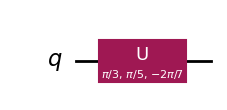

In [ ]:
quantum_register = QuantumRegister(size=1, name="q")

quantum_circuit = QuantumCircuit(quantum_register, name="example circuit")

# add a phase gate
quantum_circuit.u(np.pi / 3, np.pi / 5, - 2 * np.pi / 7, quantum_register[0], )

quantum_circuit.draw(output="mpl")

# controlled gates

### controlled NOT (CX) gate

https://quantum.cloud.ibm.com/docs/en/api/qiskit/qiskit.circuit.library.CXGate

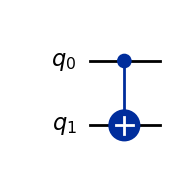

In [ ]:
quantum_register = QuantumRegister(size=2, name="q")

quantum_circuit = QuantumCircuit(quantum_register, name="example circuit")

# add CX
quantum_circuit.cx(quantum_register[0], quantum_register[1])

quantum_circuit.draw(output="mpl")

### note: controlled versions of gates require picking a "gauge", that is, a concrete representation of the gate; for example, the controlled RZ and controlled phase gates are not physically equivalent, even though the original gates are!

In [ ]:
quantum_register = QuantumRegister(size=2, name="q")

quantum_circuit = QuantumCircuit(quantum_register, name="example circuit")

quantum_circuit.crz(np.pi / 3, quantum_register[0], quantum_register[1])

O1 = Operator(quantum_circuit)

###

quantum_register = QuantumRegister(size=2, name="q")

quantum_circuit = QuantumCircuit(quantum_register, name="example circuit")

# add CX
quantum_circuit.cp(np.pi / 3, quantum_register[0], quantum_register[1])

O2 = Operator(quantum_circuit)


# check if they are equivalent:
O1.equiv(O2)

False